<a href="https://colab.research.google.com/github/auliatauhid/Data-Science-2026/blob/main/Pertemuan13_AuliaTauhid_250401020136.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Nama:** Aulia Tauhid Akbar
**NIM:** 250401020136
**Kelas:** Data Science (IF405)

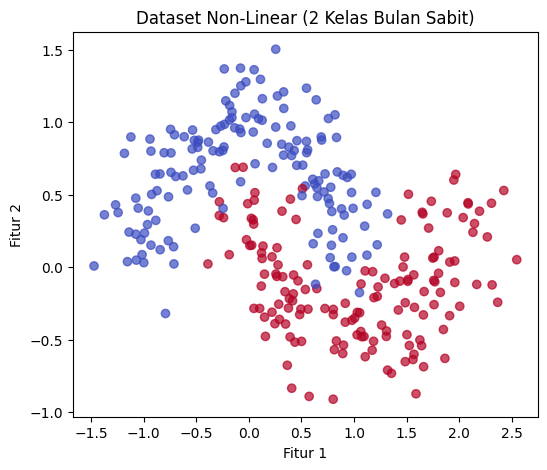

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=300, noise=0.2, random_state=42)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', alpha=0.7)
plt.title('Dataset Non-Linear (2 Kelas Bulan Sabit)')
plt.xlabel('Fitur 1')
plt.ylabel('Fitur 2')
plt.show()

# Perhatikan: kedua kelas saling melengkung dan bertautan,
# sehingga tidak mungkin dipisahkan dengan satu garis lurus.

In [2]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = Sequential([
    Dense(16, activation='relu', input_shape=(2,)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy',
              metrics=['accuracy'])
model.summary()

history = model.fit(X_tr, y_tr, epochs=30,
                     validation_split=0.2, verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

Akurasi pada data uji: 0.900


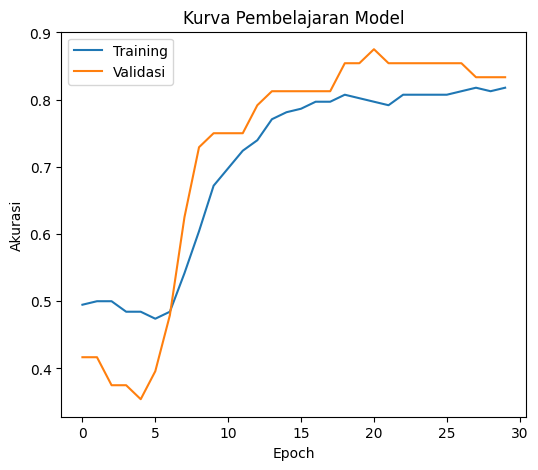

In [3]:
loss, acc = model.evaluate(X_te, y_te, verbose=0)
print(f'Akurasi pada data uji: {acc:.3f}')

plt.figure(figsize=(6, 5))
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validasi')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()
plt.title('Kurva Pembelajaran Model')
plt.show()

In [4]:
ulasan = [
    'Barangnya bagus banget, pengiriman cepat',
    'Kualitas jelek, tidak sesuai deskripsi',
    'Sangat puas, akan beli lagi',
    'Kecewa, barang rusak saat sampai',
    'Recommended, harga sesuai kualitas',
    'Buruk sekali, tidak sesuai ekspektasi',
    'Produk original dan berkualitas tinggi',
    'Pengiriman lambat dan packing berantakan',
    'Pelayanan ramah, respon cepat',
    'Barang tidak sesuai gambar, kecewa berat',
    'Harga murah tapi kualitas bagus',
    'Ukuran tidak sesuai, mengecewakan',
    'Suka banget, warnanya cantik',
    'Bahan tipis dan mudah rusak',
    'Cepat sampai dan sesuai pesanan',
    'Komplain tidak ditanggapi penjual',
    'Kualitas premium, worth it',
    'Barang cacat, minta refund',
    'Sangat rekomendasi buat yang mau beli',
    'Mengecewakan, tidak akan beli lagi',
    'Fast respon dan pengemasan rapi',
    'Kain kasar, tidak nyaman dipakai',
    'Puas dengan hasilnya, sesuai ekspektasi',
    'Barang datang dalam kondisi rusak',
    'Kualitas oke, pengiriman on time',
    'Ukuran kekecilan, tidak sesuai chart',
    'Toko terpercaya, barang original',
    'Produk palsu, sangat mengecewakan',
    'Recommended seller, fast respon',
    'Barang tidak berfungsi, sia-sia beli',
    'Sesuai deskripsi dan harga bersahabat',
    'Pelayanan buruk dan lambat',
    'Kualitas bahan sangat bagus dan halus',
    'Warna belang dan jahitan lepas',
    'Belanja aman dan barang berkualitas',
    'Sangat kecewa dengan pelayanan toko ini',
    'Top quality, sesuai foto',
    'Pengiriman terlambat sangat lama',
    'Puas banget, akan repeat order',
    'Barang murahan dan tidak awet'
]

label = [
    1, 0, 1, 0, 1, 0,
    1, 0, 1, 0,
    1, 0, 1, 0, 1,
    0, 1, 0, 1, 0,
    1, 0, 1, 0, 1,
    0, 1, 0, 1, 0,
    1, 0, 1, 0, 1,
    0, 1, 0, 1, 0
]

print(f'Jumlah ulasan: {len(ulasan)}')
print(f'Jumlah label: {len(label)}')


Jumlah ulasan: 40
Jumlah label: 40


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
X_text = tfidf.fit_transform(ulasan)

print('Jumlah kata unik:', len(tfidf.get_feature_names_out()))
print(tfidf.get_feature_names_out()[:10])

Jumlah kata unik: 103
['akan' 'aman' 'awet' 'bagus' 'bahan' 'banget' 'barang' 'barangnya'
 'belang' 'belanja']


In [6]:
# (Opsional) Lihat kata dengan skor TF-IDF rata-rata tertinggi
import numpy as np

skor_rata2 = np.asarray(X_text.mean(axis=0)).flatten()
top_idx = skor_rata2.argsort()[::-1][:10]
fitur = tfidf.get_feature_names_out()

print('Top 10 kata dengan skor TF-IDF tertinggi:')
for i in top_idx:
    print(f'{fitur[i]}: {skor_rata2[i]:.4f}')

Top 10 kata dengan skor TF-IDF tertinggi:
sesuai: 0.0825
dan: 0.0820
tidak: 0.0783
barang: 0.0652
kualitas: 0.0568
sangat: 0.0540
pengiriman: 0.0407
beli: 0.0379
mengecewakan: 0.0378
harga: 0.0359


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(
    X_text, label, test_size=0.2, random_state=42)

model_sentimen = LogisticRegression()
model_sentimen.fit(Xt_tr, yt_tr)

akurasi = model_sentimen.score(Xt_te, yt_te)
print(f'Akurasi model sentimen: {akurasi:.3f}')

kalimat_baru = ['Pelayanan sangat memuaskan dan ramah']
pred = model_sentimen.predict(tfidf.transform(kalimat_baru))
print('Positif' if pred[0] == 1 else 'Negatif')

Akurasi model sentimen: 0.625
Positif
